In [1]:
import cv2
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p

height: 863, width: 1439


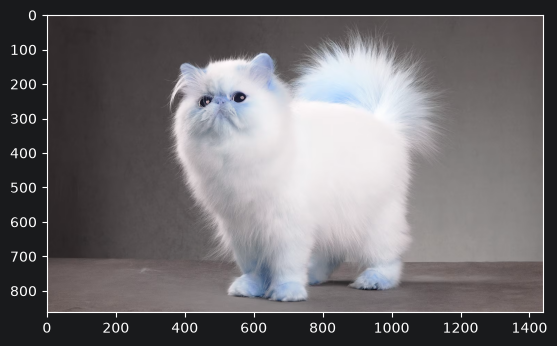

In [2]:
img1_path = p.IMAGE_ASSETS / "cat1.png"
img1 = cv2.imread(img1_path)
height1, width1, _ = img1.shape

print(f"height: {height1}, width: {width1}")

plt.figure()
plt.imshow(img1)

height: 801, width: 1200


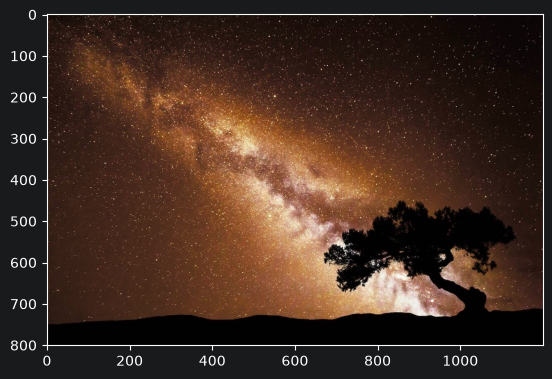

In [3]:
img2_path = p.IMAGE_ASSETS / "night_sky.jpg"
img2 = cv2.imread(img2_path)
height, width, _ = img2.shape

print(f"height: {height}, width: {width}")

plt.figure()
plt.imshow(img2)

In [4]:
scale_factor = width / width1
scale_factor

0.8339124391938847

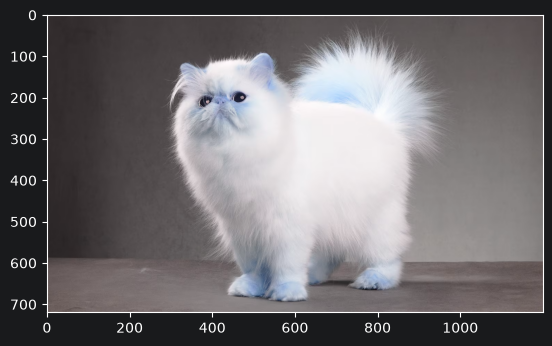

In [5]:
cat_scaled = cv2.resize(img1, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)

plt.figure()
plt.imshow(cat_scaled)

In [6]:
cat_scaled_h, cat_scaled_w, _ = cat_scaled.shape

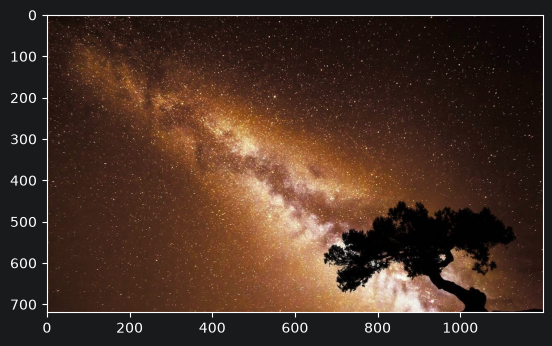

In [7]:
y0 = 0
x0 = 0

sky_bg = img2[y0:y0+cat_scaled_h, x0:x0+cat_scaled_w]
plt.figure()
plt.imshow(sky_bg)

In [8]:
def blended_trackbar_callback(input):
    pass

In [9]:
window_name = "blended_image"

scale = 100
cv2.namedWindow(window_name)
cv2.createTrackbar("alpha", window_name, 50, 1 * scale, blended_trackbar_callback)
cv2.createTrackbar("gamma", window_name, 0, 255, blended_trackbar_callback)

In [10]:

while True:
    if cv2.waitKey(1) == ord('q'):
        break

    alpha = cv2.getTrackbarPos("alpha", window_name) / scale
    gamma = cv2.getTrackbarPos("gamma", window_name)
    beta =  1 - alpha

    blended = cv2.addWeighted(cat_scaled, alpha, sky_bg, beta, gamma)

    cv2.imshow(window_name, blended)

cv2.destroyAllWindows()
